# <center> Multi-Channel Queuing Example
## <center> Systems Engineering and Analysis
## <center> <img src="https://www.engr.colostate.edu/~jdaily/Systems-EN-CSU-1-C357.svg" width="400" /> 
### <center> Prepared by: Dr. Jeremy Daily

Note: This notebook was generated by asking ChatGPT 5.2 to take the single channel queuing notebook and model a quicklube shop. The 

## A simple M/M/c example: a quick-lube shop

A better M/M/c example is a quick-lube service shop:

- cars arrive randomly,
- there is one common waiting line,
- there are \(c\) identical service bays,
- and each bay has a random service time with the same average rate.

That matches the assumptions behind the standard M/M/c model much better.

In this notebook we will keep the model simple:

- Poisson arrivals with rate \(\lambda\),
- exponential service times with rate \(\mu\) per bay,
- and \(c\) parallel bays.

We will compare the standard queueing formulas to a lightweight event-driven simulation.

A ski-lift line is a good example of a capacity bottleneck, but it was not really a textbook M/M/c system because riders leave in batches on a chair at the same time.


## M/M/c theory
The closed form theory for M/M/c queues are explained in https://en.wikipedia.org/wiki/M/M/c_queue and presented as follows.

Let

$\lambda = $ arrival rate

$\mu = $ service rate of one bay

$c = $ number of bays

$a = \frac{\lambda}{\mu}$
$\rho = \frac{\lambda}{c\mu}$

The system is stable only when $\rho < 1$.

For an M/M/c queue, the standard formulas are:

$$ P_0 = \left[\sum_{n=0}^{c-1}\frac{a^n}{n!} + \frac{a^c}{c!}\frac{1}{1-\rho}
\right]^{-1} $$


$$P_k = \frac{a^c}{c!}\frac{1}{1-\rho} P_0 $$

$$L_q = P_0 \cdot \frac{a^c \rho}{c!(1-\rho)^2}$$


$$ W_q = \frac{L_q}{\lambda}, \qquad
W = W_q + \frac{1}{\mu}, \qquad
L = L_q + \frac{\lambda}{\mu}$$


These will give us the steady-state values to compare against the simulation.


In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def mmc_theory(arrival_rate, service_rate, servers):
    """Return standard M/M/c steady-state formulas."""
    lam = float(arrival_rate)
    mu = float(service_rate)
    c = int(servers)

    if lam <= 0 or mu <= 0 or c <= 0:
        raise ValueError("arrival_rate, service_rate, and servers must be positive.")

    rho = lam / (c * mu)
    if rho >= 1.0:
        raise ValueError("System is unstable because lambda >= c * mu.")

    a = lam / mu

    series_sum = 0.0
    for n in range(c):
        series_sum += a**n / math.factorial(n)

    tail = (a**c / math.factorial(c)) * (1.0 / (1.0 - rho))
    P0 = 1.0 / (series_sum + tail)

    P_wait = tail * P0
    Lq = P0 * (a**c) * rho / (math.factorial(c) * (1.0 - rho)**2)
    Wq = Lq / lam
    W = Wq + 1.0 / mu
    L = Lq + a

    return {
        "lambda": lam,
        "mu": mu,
        "c": c,
        "rho": rho,
        "P0": P0,
        "P_wait": P_wait,
        "Lq": Lq,
        "Wq_hours": Wq,
        "W_hours": W,
        "Wq_minutes": 60.0 * Wq,
        "W_minutes": 60.0 * W,
        "L": L,
    }

## A quick-lube example

Suppose:

- cars arrive at 8 cars per hour
- each bay services cars at an average rate of 4 cars per hour
- the shop has 3 identical bays

In [3]:
arrival_rate = 8 #150   # cars per hour
service_rate = 4 #18   # cars per hour per bay
servers = 3 #12

theory = mmc_theory(arrival_rate, service_rate, servers)

for key, value in theory.items():
    if isinstance(value, float):
        print(f"{key:12s}: {value:.6f}")
    else:
        print(f"{key:12s}: {value}")

lambda      : 8.000000
mu          : 4.000000
c           : 3
rho         : 0.666667
P0          : 0.111111
P_wait      : 0.444444
Lq          : 0.888889
Wq_hours    : 0.111111
W_hours     : 0.361111
Wq_minutes  : 6.666667
W_minutes   : 21.666667
L           : 2.888889


In [4]:
if theory['rho'] < 1:
    print(f"Since rho = {theory['rho']}, which is less than 1, the system is stable.")
else:
    print(f"Since rho = {theory['rho']}, which is more than 1, the system is unstable and may diverge over time.")

Since rho = 0.6666666666666666, which is less than 1, the system is stable.


## Event-driven simulation

We can simulate the system by jumping from one event to the next:

1. the next arrival
2. the next service completion

To keep the code lightweight:

- we store the completion time for each bay in a simple NumPy array,
- we find the next completion with `argmin`,
- and we store waiting arrivals in a plain Python list with a moving index.

This is still event-driven, so it converges much faster than a tiny time-step simulation.


In [5]:
def simulate_mmc(arrival_rate,
                 service_rate,
                 servers,
                 completed_customers=100_000,
                 seed=1,
                 checkpoints=None):
    """
    Event-driven simulation of an M/M/c queue.

    Parameters
    ----------
    arrival_rate : float
        Arrival rate lambda.
    service_rate : float
        Service rate mu for one server.
    servers : int
        Number of parallel identical servers.
    completed_customers : int
        Number of service completions to record.
    seed : int
        Random seed for reproducibility.
    checkpoints : list[int] or None
        Completion counts at which intermediate estimates are saved.

    Returns
    -------
    dict
        Time-average and customer-average estimates.
    """
    lam = float(arrival_rate)
    mu = float(service_rate)
    c = int(servers)

    if lam <= 0 or mu <= 0 or c <= 0:
        raise ValueError("arrival_rate, service_rate, and servers must be positive.")
    if lam >= c * mu:
        raise ValueError("System is unstable because lambda >= c * mu.")

    rng = np.random.default_rng(seed)

    # State variables
    t = 0.0
    next_arrival = rng.exponential(1.0 / lam)
    busy_until = np.full(c, np.inf, dtype=float)  # inf means idle
    queue_arrivals = []
    queue_head = 0

    # Statistics
    completed = 0
    total_wait = 0.0
    total_system = 0.0
    total_service = 0.0
    area_n = 0.0
    area_q = 0.0
    last_t = 0.0
    
    while completed < completed_customers:
        next_departure_idx = int(np.argmin(busy_until))
        next_departure = busy_until[next_departure_idx]

        if next_arrival <= next_departure:
            t = next_arrival

            busy_count = np.isfinite(busy_until).sum()
            queue_length = len(queue_arrivals) - queue_head
            delta_t = (t - last_t)
            area_n += (busy_count + queue_length) * delta_t 
            area_q += queue_length * delta_t 
            last_t = t

            idle = np.where(~np.isfinite(busy_until))[0]
            if idle.size > 0:
                bay = int(idle[0])
                service_time = rng.exponential(1.0 / mu)
                busy_until[bay] = t + service_time
                total_service += service_time
                total_system += service_time
            else:
                queue_arrivals.append(t)
            
            next_arrival = t + rng.exponential(1.0 / lam)

        else:
            t = next_departure

            busy_count = np.isfinite(busy_until).sum()
            queue_length = len(queue_arrivals) - queue_head
            delta_t = (t - last_t)
            area_n += (busy_count + queue_length) * delta_t
            area_q += queue_length * delta_t
            last_t = t

            completed += 1

            if queue_head < len(queue_arrivals):
                arrival_time_of_next = queue_arrivals[queue_head]
                queue_head += 1

                wait = t - arrival_time_of_next
                service_time = rng.exponential(1.0 / mu)

                total_wait += wait
                total_service += service_time
                total_system += wait + service_time

                busy_until[next_departure_idx] = t + service_time
            else:
                busy_until[next_departure_idx] = np.inf
            
    total_time = t
    throughput = completed / total_time
    L = area_n / total_time
    Lq = area_q / total_time
    Wq = total_wait / completed
    W = total_system / completed
    mean_service = total_service / completed

    return {
        "completed": completed,
        "time_hours": total_time,
        "throughput": throughput,
        "L": L,
        "Lq": Lq,
        "Wq_hours": Wq,
        "W_hours": W,
        "Wq_minutes": 60.0 * Wq,
        "W_minutes": 60.0 * W,
        "mean_service_hours": mean_service,
        "mean_service_minutes": 60.0 * mean_service,
    }

In [6]:
results = simulate_mmc(
    arrival_rate=arrival_rate,
    service_rate=service_rate,
    servers=servers,
    completed_customers=100_000,
    seed=42
)

for key, value in results.items():
    if isinstance(value, float):
        print(f"{key:22s}: {value:.6f}")
    else:
        print(f"{key:22s}: {value}")

completed             : 100000
time_hours            : 12526.669291
throughput            : 7.982968
L                     : 2.848191
Lq                    : 0.860470
Wq_hours              : 0.107788
W_hours               : 0.356784
Wq_minutes            : 6.467295
W_minutes             : 21.407011
mean_service_hours    : 0.248995
mean_service_minutes  : 14.939716


The simulation starts with an **empty shop**, so the early part of the run has a little start-up bias.  
For now, we will keep that because it keeps the notebook simple. Later, a warm-up period is a natural next refinement.

Even without a warm-up period, a long run should still get quite close to the steady-state theory.


In [7]:
print("Theory vs simulation")
print("-" * 50)
print(f"L   theory = {theory['L']:.6f}     simulation = {results['L']:.6f}")
print(f"Lq  theory = {theory['Lq']:.6f}     simulation = {results['Lq']:.6f}")
print(f"W   theory = {theory['W_minutes']:.6f} min  simulation = {results['W_minutes']:.6f} min")
print(f"Wq  theory = {theory['Wq_minutes']:.6f} min  simulation = {results['Wq_minutes']:.6f} min")
print(f"throughput ≈ lambda =  {arrival_rate:.6f} vs {results['throughput']:.6f}")

Theory vs simulation
--------------------------------------------------
L   theory = 2.888889     simulation = 2.848191
Lq  theory = 0.888889     simulation = 0.860470
W   theory = 21.666667 min  simulation = 21.407011 min
Wq  theory = 6.666667 min  simulation = 6.467295 min
throughput ≈ lambda = 7.982968 vs 8.000000


In [8]:
# Little's Law checks
print(f"Lq from time average        = {results['Lq']:.6f}")
print(f"lambda * Wq                 = {arrival_rate * results['Wq_hours']:.6f}")
print()
print(f"L from time average         = {results['L']:.6f}")
print(f"lambda * W                  = {arrival_rate * results['W_hours']:.6f}")

Lq from time average        = 0.860470
lambda * Wq                 = 0.862306

L from time average         = 2.848191
lambda * W                  = 2.854268


## Convergence check

A simple way to see convergence is to watch the estimates as the number of completed services grows.


## Optional staffing study

This last cell changes the number of service bays while keeping the same arrival and service rates.  
It shows a common queueing lesson: as utilization gets closer to 1, the average waiting time rises quickly.


bays   rho      theory Wq (min)   simulation Wq (min)
   1   unstable   not defined         not simulated
   2   unstable   not defined         not simulated
   3   0.667          6.6667             6.6391
   4   0.500          1.3043             1.3167
   5   0.400          0.2985             0.2945
   6   0.333          0.0676             0.0653
   7   0.286          0.0144             0.0149


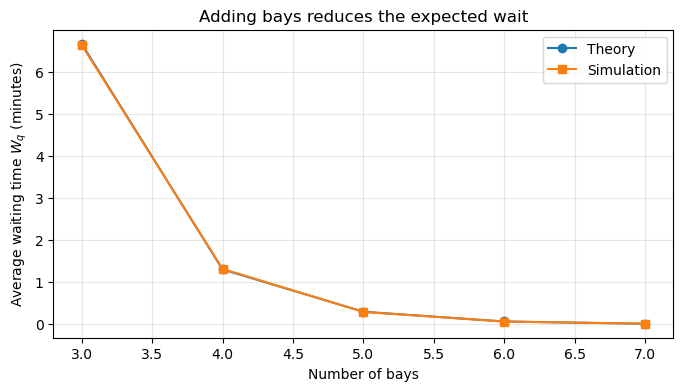

In [9]:
bay_choices = [n for n in range(1,8)]

stable_bays = []
rho_values = []
theory_Wq = []
sim_Wq = []

print("bays   rho      theory Wq (min)   simulation Wq (min)")
for c in bay_choices:
    if arrival_rate >= c * service_rate:
        print(f"{c:4d}   unstable   not defined         not simulated")
        continue

    th = mmc_theory(arrival_rate, service_rate, c)
    sim = simulate_mmc(arrival_rate, service_rate, c, completed_customers=400_000, seed=20 + c)

    stable_bays.append(c)
    rho_values.append(th["rho"])
    theory_Wq.append(th["Wq_minutes"])
    sim_Wq.append(sim["Wq_minutes"])

    print(f"{c:4d}  {th['rho']:6.3f}      {th['Wq_minutes']:10.4f}         {sim['Wq_minutes']:10.4f}")

plt.figure(figsize=(8, 4))
plt.plot(stable_bays, theory_Wq, marker="o", label="Theory")
plt.plot(stable_bays, sim_Wq, marker="s", label="Simulation")
plt.xlabel("Number of bays")
plt.ylabel("Average waiting time $W_q$ (minutes)")
plt.title("Adding bays reduces the expected wait")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()